In [78]:
### Import Libraries

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn import datasets
from sklearn.metrics import (accuracy_score,
                             classification_report,
                                confusion_matrix,
                                ConfusionMatrixDisplay,
                                f1_score)

In [79]:
# Directories

inpDir = Path('D:\Deep_Learning\SharedData\breast_cancer_mod.csv')
outDir = Path('D:\Deep_Learning\SharedData\breast_cancer_mod_output')

RANDOM_STATE = 24
# np.random.seed(RANDOM_STATE) # Set Random Seed for reproducible  results
rng = np.random.default_rng(seed=RANDOM_STATE) # Create a random number generator with the specified seed

NOISE = 0.2
EPOCHS = 200
ALPHA = 0.001
N_SAMPLES = 1000
TEST_SIZE  = 0.2 # Size of test data

# Parameters for plotting
params = {'legend.fontsize': 'medium',
          'figure.figsize': (15, 6),
          'axes.labelsize': 'large',
          'axes.titlesize':'large',
          'xtick.labelsize':'medium',
          'ytick.labelsize':'medium'
         }

CMAP = plt.cm.coolwarm

plt.rcParams.update(params)

plt.style.use('seaborn-v0_8-darkgrid')   # plt.style.use('ggplot')

In [80]:
X,y = datasets.make_moons(n_samples=N_SAMPLES,
                          noise=NOISE,
                          shuffle=True,
                          random_state=RANDOM_STATE)
X[:5], y[:5]

(array([[ 0.90633951,  0.90267624],
        [-1.11536828,  0.75579289],
        [ 1.88769158,  0.4175967 ],
        [-0.93345034, -0.02299851],
        [-0.96872877,  0.06396285]]),
 array([0, 0, 1, 0, 0]))

In [81]:
data_df = pd.DataFrame(X, columns=['A', 'B'])
data_df['target'] = y
data_df.head()

,A,B,target
0,0.906340,0.902676,0
1,-1.115368,0.755793,0
2,1.887692,0.417597,1
3,-0.933450,-0.022999,0
4,-0.968729,0.063963,0


<Axes: xlabel='A', ylabel='B'>

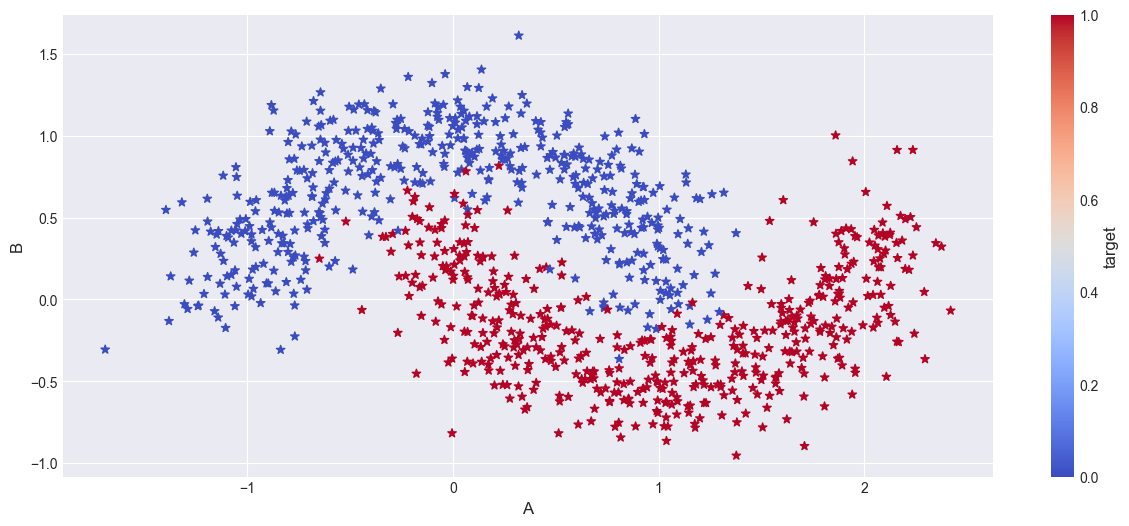

In [82]:
data_df.plot.scatter('A','B', s=40, marker='*', c='target', cmap=CMAP)

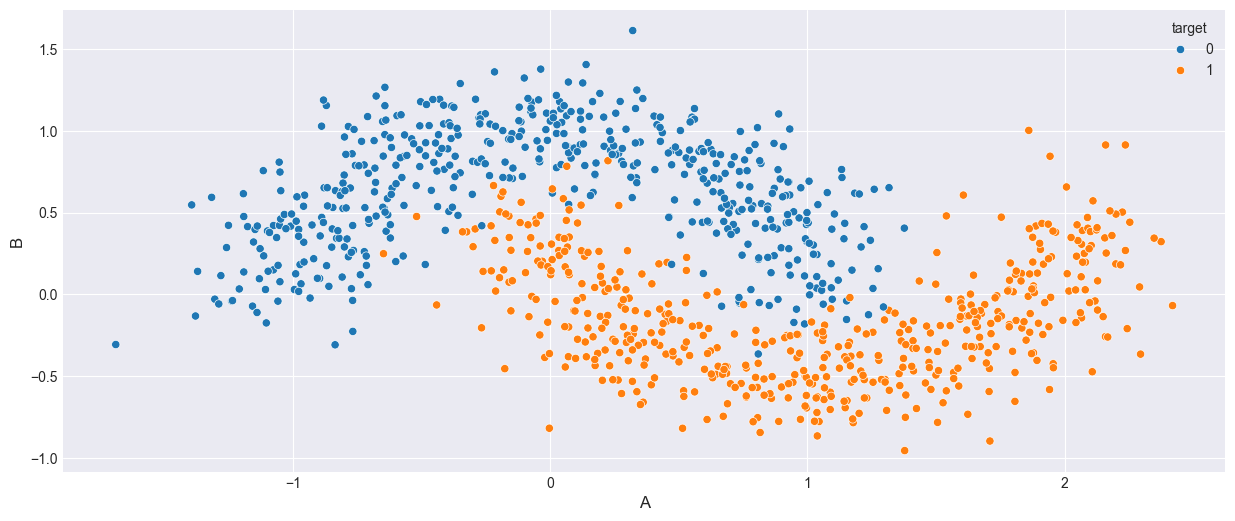

In [83]:
ax = sns.scatterplot(x='A', y='B', hue='target', data=data_df)

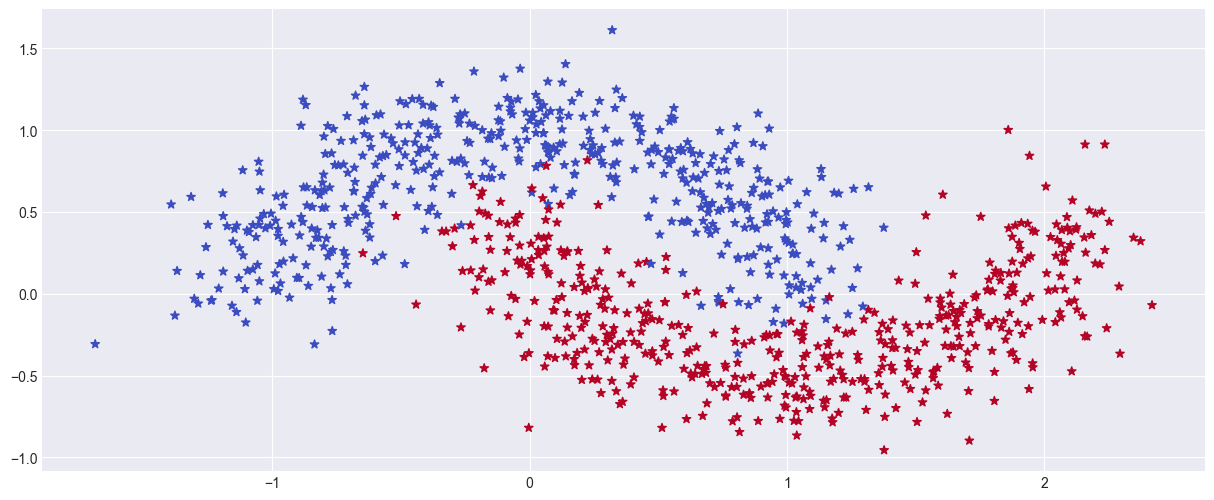

In [84]:
plt.scatter(X[:,0], X[:,1], s=40, c=y, marker='*', cmap=CMAP)

In [85]:
data_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   A       1000 non-null   float64
 1   B       1000 non-null   float64
 2   target  1000 non-null   int64  
dtypes: float64(2), int64(1)
memory usage: 23.6 KB


In [86]:
data_df.describe().T

,count,mean,std,min,25%,50%,75%,max
A,1000.0,0.490841,0.898951,-1.688795,-0.149565,0.500100,1.095048,2.419113
B,1000.0,0.239025,0.540082,-0.955280,-0.205090,0.241163,0.680394,1.612075
target,1000.0,0.500000,0.500250,0.000000,0.000000,0.500000,1.000000,1.000000


In [87]:
data_df['target'].value_counts()

target
0    500
1    500
Name: count, dtype: int64

<Axes: xlabel='target'>

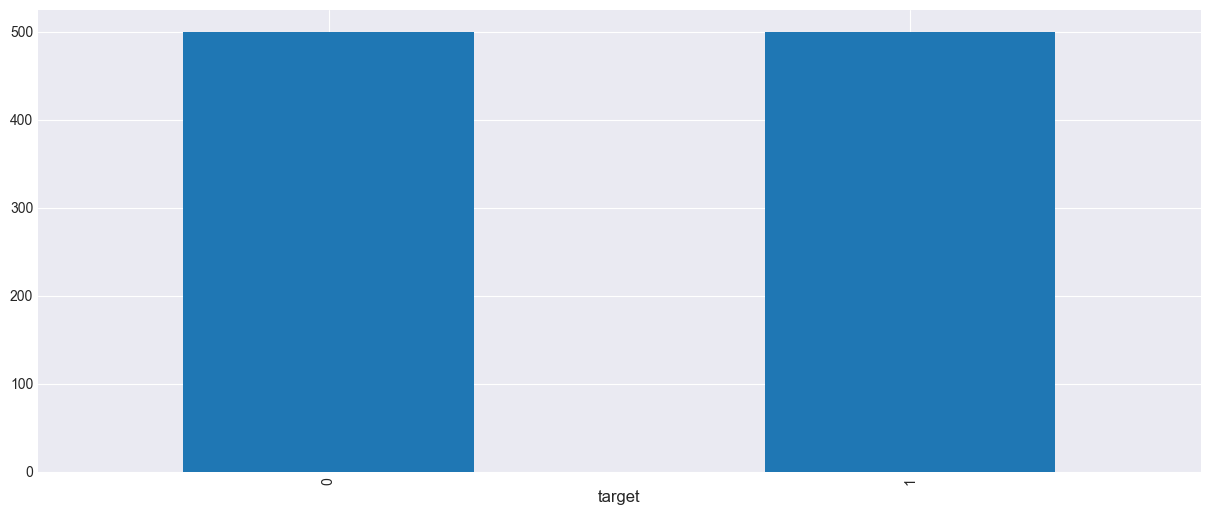

In [88]:
fig, ax = plt.subplots()

data_df['target'].value_counts().plot(ax=ax, kind='bar')

In [89]:
data_train, data_test = data_df.to_numpy()[:900], data_df.to_numpy()[900:]
data_train.shape, data_test.shape

((900, 3), (100, 3))

In [ ]:
def predict(row, weights):
    z = weights[0]   # init with b (w0)
    
    for i in range(len(row)-1):
        z += weights[i+1] * row[i]
        
    return 1 if z >=0 else 0    # simplest activation function (step function)

In [91]:
weights = np.array([0.1, 0.2, 1.0])

display(data_df.loc[0])
predict (data_df.loc[0].values, weights)

A         0.906340
B         0.902676
target    0.000000
Name: 0, dtype: float64

1

In [92]:
# rng.standard_normal(3)

In [93]:
# rng.normal(size=data_train.shape[1])

In [94]:
# rng.random(data_train.shape[1])

In [95]:
def train_weights(train, alpha=ALPHA, n_epochs = EPOCHS):
    errors=[]
    
    weights = rng.standard_normal(train.shape[1])
    
    m = train.shape[0]
    
    for epoch in range(n_epochs):
        sum_error = 0
        
        for row in train:
            prediction = predict(row, weights)
            error = prediction - row[-1]        # (a-y)
            sum_error += error**2
            weights[0] = weights[0] - alpha * error
            
            for i in range(len(row) - 1):
                weights[i+1] = weights[i+1] - alpha * error * row[i]
            
        errors.append(sum_error/m)
        
        if epoch % 10 == 0:
            print(f'Epoch {epoch:3d}: Loss ={errors[-1]: .5f}')
            
    return errors, weights

In [96]:
errors, weights = train_weights(data_train)

Epoch   0: Loss = 0.37111
Epoch  10: Loss = 0.14333
Epoch  20: Loss = 0.14000
Epoch  30: Loss = 0.13889
Epoch  40: Loss = 0.13889
Epoch  50: Loss = 0.14000
Epoch  60: Loss = 0.14444
Epoch  70: Loss = 0.16889
Epoch  80: Loss = 0.17778
Epoch  90: Loss = 0.18000
Epoch 100: Loss = 0.18444
Epoch 110: Loss = 0.17556
Epoch 120: Loss = 0.18222
Epoch 130: Loss = 0.17778
Epoch 140: Loss = 0.17889
Epoch 150: Loss = 0.18222
Epoch 160: Loss = 0.18444
Epoch 170: Loss = 0.17333
Epoch 180: Loss = 0.17111
Epoch 190: Loss = 0.17889


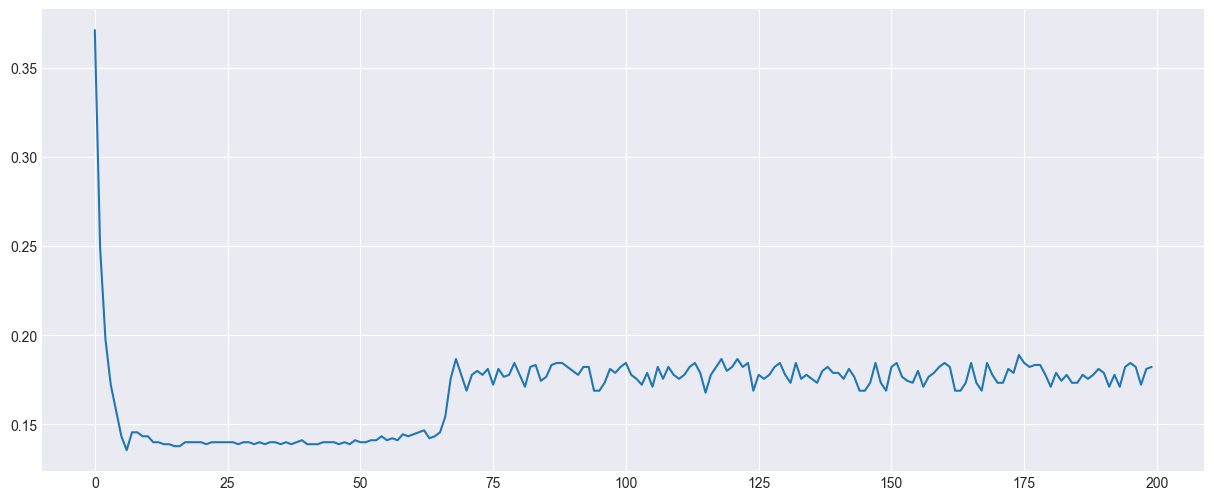

In [97]:
fig, ax = plt.subplots()
ax.plot(errors)

In [98]:
def plot_decision_boundary(X, wts):
    
    fig, ax = plt.subplots(figsize=(8,5))
    
    dm = 0.01
    margin = 10*dm
    
    x_min, x_max = X[:, 0].min() - margin, X[:, 0].max() + margin
    y_min, y_max = X[:, 1].min() - margin, X[:, 1].max() + margin
    
    xx, yy = np.meshgrid(np.arange(x_min, x_max, dm), 
                         np.arange(y_min, y_max, dm))
    
    # print(xx.shape, yy.shape)
    X_data = np.c_[xx.ravel(), yy.ravel()]
    X_data = np.hstack((X_data, np.ones((X_data.shape[0], 1))))
    
    y_pred = []
    for row in X_data:
        y_p = predict(row, wts)
        y_pred.append(y_p)
        
    Z = np.array(y_pred).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.6, cmap=plt.cm.Paired)
   
    ax.scatter(X[:,0], X[:,1], c=X[:,2], 
               s=20, edgecolor='k', cmap=CMAP)

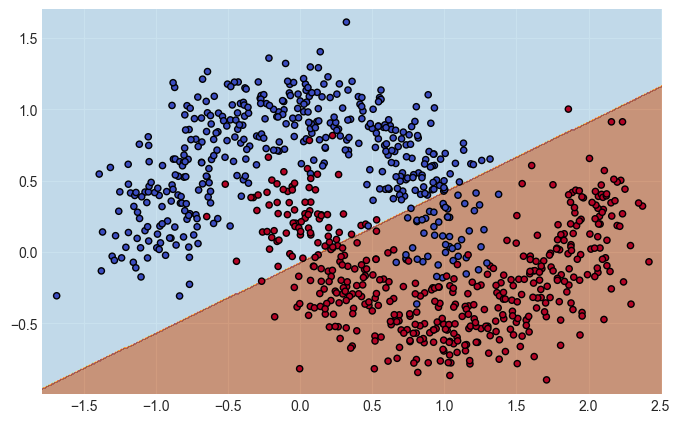

In [99]:
plot_decision_boundary(data_train, weights)

# Train

In [100]:
predictions = []
for row in data_train:
    pred = predict(row, weights)
    predictions.append(pred)
    
accuracy_score(y_true = data_train[:, -1], y_pred =  predictions)

0.8544444444444445

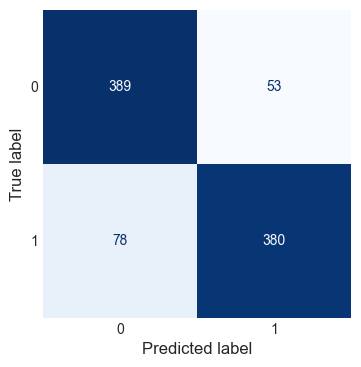

In [ ]:
cm = confusion_matrix(y_true = data_train[:, -1], y_pred = predictions)
disp = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = [0,1])

fig , ax = plt.subplots(figsize=(4,4))
disp.plot(ax = ax, cmap='Blues', colorbar=False) 
ax.grid()

# Test

In [105]:
predictions = []
for row in data_test:
    pred = predict(row, weights)
    predictions.append(pred)
    
accuracy_score(y_true = data_test[:, -1], y_pred =  predictions)

0.9

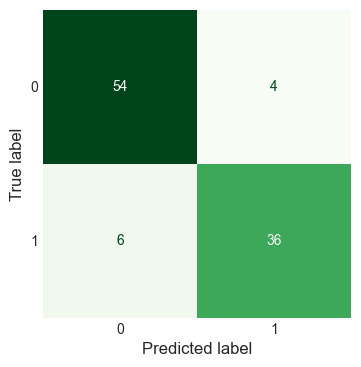

In [107]:
cm = confusion_matrix(y_true = data_test[:, -1], y_pred = predictions)
disp = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = [0,1])

fig , ax = plt.subplots(figsize=(4,4))
disp.plot(ax = ax, cmap='Greens', colorbar=False) 
ax.grid()